<a href="https://colab.research.google.com/github/ASHIKAJAN/ABC-staff-company/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving weatherHistory.csv to weatherHistory.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('weatherHistory.csv')

# First 10 rows
print("First 10 Rows")
print(df.head(10))

# Dataset information
print("\nDataset Info")
print(df.info())

# Missing values
print("\nMissing Values")
print(df.isnull().sum())

First 10 Rows
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   
5  2006-04-01 05:00:00.000 +0200  Partly Cloudy        rain         9.222222   
6  2006-04-01 06:00:00.000 +0200  Partly Cloudy        rain         7.733333   
7  2006-04-01 07:00:00.000 +0200  Partly Cloudy        rain         8.772222   
8  2006-04-01 08:00:00.000 +0200  Partly Cloudy        rain        10.822222   
9  2006-04-01 09:00:00.000 +0200  Partly Cloudy        rain        13.772222   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89        

/tmp/ipykernel_710/265777671.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Formatted Date'] = pd.to_datetime(df['Formatted Date'])


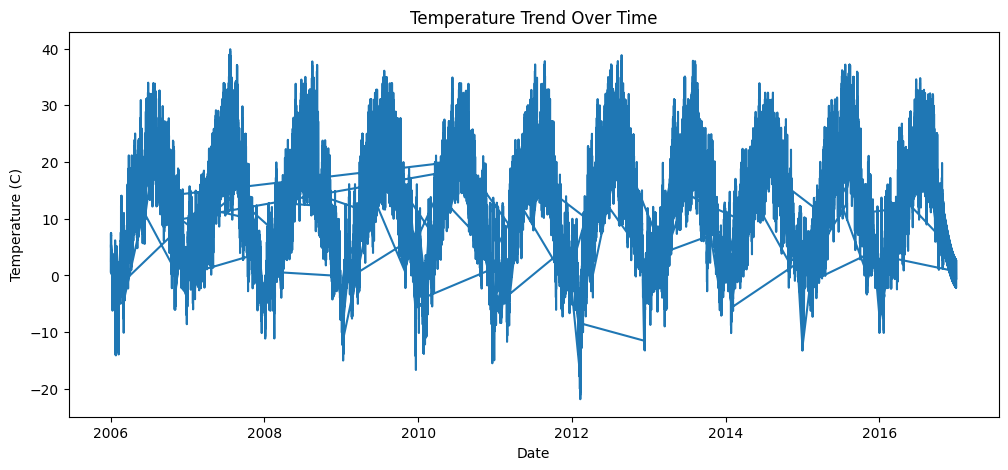

In [3]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'])

plt.figure(figsize=(12,5))
plt.plot(df['Formatted Date'], df['Temperature (C)'])
plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.show()

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Select features
data = df[['Temperature (C)',
           'Humidity',
           'Wind Speed (km/h)']]

# Handle missing values
data.fillna(data.mean(), inplace=True)

# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

print("Normalized Data Shape:", scaled_data.shape)

Normalized Data Shape: (96453, 3)


/tmp/ipykernel_710/3162608921.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.fillna(data.mean(), inplace=True)


In [5]:
import numpy as np

sequence_length = 7

X = []
y = []

for i in range(len(scaled_data)-sequence_length):
    X.append(scaled_data[i:i+sequence_length])
    y.append(scaled_data[i+sequence_length,0])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (96446, 7, 3)
y Shape: (96446,)


In [6]:
train_size = int(len(X)*0.70)
val_size = int(len(X)*0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential()

model.add(SimpleRNN(
    32,
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val,y_val)
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0019 - mae: 0.0265 - val_loss: 4.8211e-04 - val_mae: 0.0148
Epoch 2/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 6.9023e-04 - mae: 0.0182 - val_loss: 7.4147e-04 - val_mae: 0.0222
Epoch 3/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 6.4436e-04 - mae: 0.0172 - val_loss: 4.3644e-04 - val_mae: 0.0142
Epoch 4/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 6.3151e-04 - mae: 0.0169 - val_loss: 4.3146e-04 - val_mae: 0.0139
Epoch 5/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 6.1849e-04 - mae: 0.0165 - val_loss: 6.4335e-04 - val_mae: 0.0199
Epoch 6/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 6.2173e-04 - mae: 0.0166 - val_loss: 4.0034e-04 - val_mae: 0.0134
Epoch 7/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 6.1358e-04 - mae: 0.0165 - val_loss: 4.1262e-04 - val_mae: 0.0137
Epoch 8/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 6.1317e-04 - mae: 0.0164 - val_loss: 3.8315e-04 - val_mae

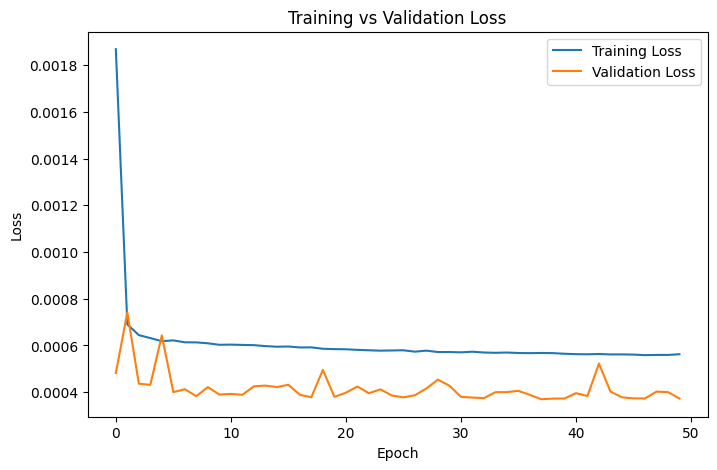

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RMSE = 0.01834983348452768
MAE = 0.012425872196501032
R2 Score = 0.983936347416612


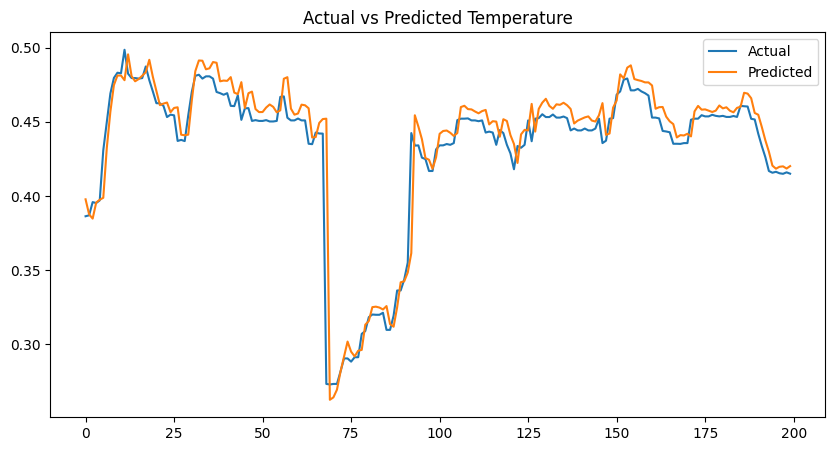

Next 7 Days Forecast:
[np.float32(0.6817671), np.float32(0.6633538), np.float32(0.64662033), np.float32(0.6322501), np.float32(0.620934), np.float32(0.61156374), np.float32(0.60432607)]


In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Predictions
pred = model.predict(X_test)

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test,pred))
mae = mean_absolute_error(y_test,pred)
r2 = r2_score(y_test,pred)

print("RMSE =", rmse)
print("MAE =", mae)
print("R2 Score =", r2)

# Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(y_test[:200], label='Actual')
plt.plot(pred[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Temperature")
plt.show()

# Forecast next 7 days
last_seq = X[-1]
forecast = []

for i in range(7):

    next_temp = model.predict(
        last_seq.reshape(1,7,3),
        verbose=0
    )[0][0]

    forecast.append(next_temp)

    new_row = last_seq[-1].copy()
    new_row[0] = next_temp

    last_seq = np.vstack(
        [last_seq[1:], new_row]
    )

print("Next 7 Days Forecast:")
print(forecast)